In [1]:
%load_ext autoreload
%autoreload 2

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
from scipy.stats import chi2
import cloudpickle as pickle
from astropy.cosmology import FlatLambdaCDM

from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from lightcurvelynx.validation.lcfit import fit_single_lc

from utils.plotting_utils import (plot_snr_distr, 
                                plot_logflux_vs_logfluxerr, 
                                plot_logmaxflux_vs_logmaxfluxerr,
                                convert_flux_to_mag,
                                plot_mag_vs_magerr,
                                convert_flux_to_njy,
                                plot_flux_vs_fluxerr,
                                )

In [3]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [4]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [5]:
lightcurves = read_parquet('results/lightcurves.parquet')

In [6]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})

In [7]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  199.481034  41.838571  1105  59074.599915  0.156601   
1   1   59.985667 -15.129433   657  58487.141962  0.136212   
2   2  355.108559 -23.011061   281  58491.445278  0.183541   
3   3  199.699635  21.748234    57  58796.641552  0.186285   
4   4  348.991442  78.269723   662  58552.781052  0.133693   

                                              params  \
0  {'DistModFromRedshift:_distmod_from_redshift_9...   
1  {'DistModFromRedshift:_distmod_from_redshift_9...   
2  {'DistModFromRedshift:_distmod_from_redshift_9...   
3  {'DistModFromRedshift:_distmod_from_redshift_9...   
4  {'DistModFromRedshift:_distmod_from_redshift_9...   

                                                  lc  pass_spec_selection  \
0  [{mjd: 58288.222656, filter: 'g', flux: -2528....                False   
1  [{mjd: 58335.5, filter: 'g', flux: -452.064582...                False   
2  [{mjd: 58304.480469, filter: 'g', flux: 2719.3...                False   
3  [{mjd: 58449.519531, filter: 'r', flux: 4013.1...                False   
4  [{mjd: 58288.410156, filter: 'g', flux: 2628.4...                False   

   pass_quality_cuts  
0              False  
1              False  
2              False  
3              False  
4              False

In [8]:
lightcurves['params'][0].keys()

dict_keys(['DistModFromRedshift:_distmod_from_redshift_9.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_9.redshift', 'NumpyRandomFunc:exponential_6.function_node_result', 'NumpyRandomFunc:exponential_6.scale', 'NumpyRandomFunc:normal_10.function_node_result', 'NumpyRandomFunc:normal_10.loc', 'NumpyRandomFunc:normal_10.scale', 'NumpyRandomFunc:uniform_7.function_node_result', 'NumpyRandomFunc:uniform_7.high', 'NumpyRandomFunc:uniform_7.low', 'SamplePDF:_rvs_4.function_node_result', 'host.dec', 'host.distance', 'host.hostmass', 'host.ra', 'host.redshift', 'host.t0', 'mwext.dec', 'mwext.ebv', 'mwext.ra', 'pznode.c', 'pznode.mass', 'pznode.x1', 'radec.dec', 'radec.ra', 'sncoor_node.dec', 'sncoor_node.host_dec', 'sncoor_node.host_ra', 'sncoor_node.physical_sep_kpc', 'sncoor_node.ra', 'sncoor_node.redshift', 'source.Rv', 'source.c', 'source.dec', 'source.distance', 'source.ebv', 'source.ra', 'source.redshift', 'source.t0', 'source.x0', 'source.x1', 'x0_func.alpha', 'x0_fu

In [9]:
print("Before applying detection: nsn=", len(lightcurves))
lightcurves_after_detection = lightcurves.query("lc.detection_flag==True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))
lightcurves_after_spec_selection = lightcurves.loc[lightcurves['pass_spec_selection']]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))
lightcurves_after_quality_cut = lightcurves.loc[lightcurves['pass_quality_cuts']]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

Before applying detection: nsn= 128754


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After applying detection: nsn= 54409
After spectroscopic selection: nsn= 3481
After quality cuts: nsn= 2693


In [10]:
with open("results/saved_model_and_passband.pkl", "rb") as file:  
    lynx_model, passband_group = pickle.load(file)

INFO:2025-10-01 10:22:27,526:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-10-01 10:22:27,526 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-10-01 10:22:27,527:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/mi/anaconda3/envs/lightcurvelynx/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
2025-10-01 10:22:27,527 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboo

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


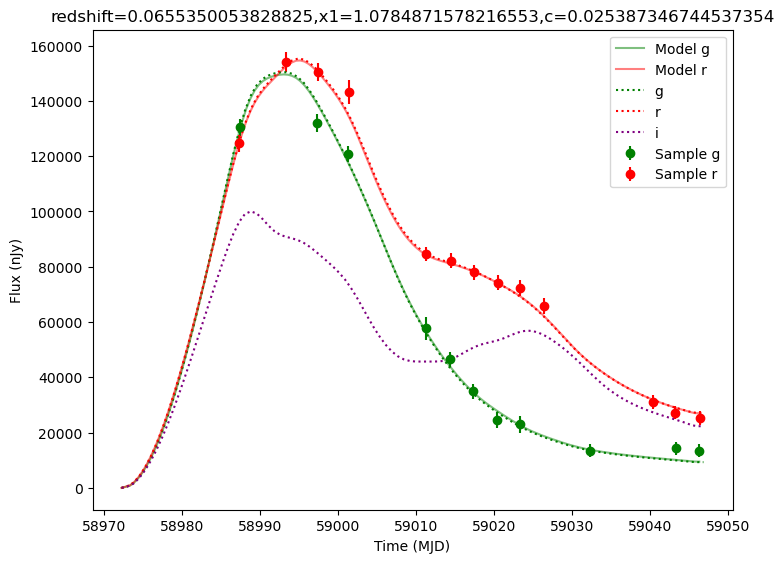

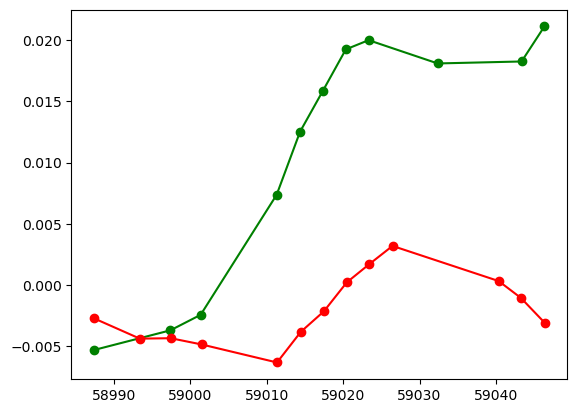

In [11]:
sncosmo_modelname = "salt3"
random_ids = lightcurves_after_quality_cut.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}
# random_ids=[1032]

for random_id in random_ids:
    # Extract the row for this object.
    # lc = lightcurves.loc[lightcurves.id==random_id]
    lc = lightcurves_after_quality_cut.loc[lightcurves_after_quality_cut.id==random_id]
    lc = lc.query("lc.detection_flag==True")
    
    state = GraphState.from_dict(lc.iloc[0]["params"])
    noise_free_lcs = compute_single_noise_free_lightcurve(
        lynx_model,
        state,
        passband_group,
        rest_frame_phase_min=-20.0, 
        rest_frame_phase_max=50.0, 
        rest_frame_phase_step=0.5, 
    )
    
    if lc["nobs"].values[0] > 0:
        # Unpack the nested columns (filters, mjd, flux, and flux error).
        lc_filters = np.asarray(lc["lc.filter"], dtype=str)
        lc_mjd = np.asarray(lc["lc.mjd"], dtype=float)
        lc_flux = np.asarray(lc["lc.flux"], dtype=float)
        lc_fluxerr = np.asarray(lc["lc.fluxerr"], dtype=float)
        
        lc_mag = -2.5*np.log10(lc_flux) + 31.4
        lc_magerr = np.absolute(1.086*lc_fluxerr/lc_flux)
        
        plot_lightcurves(
            fluxes=lc_flux,
            times=lc_mjd,
            fluxerrs=lc_fluxerr,
            filters=lc_filters,
            colormap=colormap,
            underlying_model=noise_free_lcs,
        )
        plt.ylabel('Flux (nJy)')
        # plt.title(f"redshift={lc['z']},mwebv={lc['params'].values[0]['mwext.ebv']}")
        plt.title(f"redshift={lc['z'].values[0]},x1={lc['params'].values[0]['source.x1']},c={lc['params'].values[0]['source.c']}")

        model = sncosmo.Model(source=sncosmo_modelname,
                      effects=[sncosmo.F99Dust()],
                      effect_names=['mw'],
                      effect_frames=['obs'])
        pardict = {}
        for p in ['x0','x1','c','t0']:
            pardict[p] = lc['params'].values[0][f'source.{p}']
        pardict['mwebv'] = lc['params'].values[0]['mwext.ebv']
        pardict['z'] = lc['z'].values[0]
        model.update(pardict)
        t = np.linspace(-20,50,100)
        obstime = t*(1+pardict['z'])+pardict['t0']
        sncosmo_flux = {}
        lynx_flux = {}
        mjd = {}
        for b in 'gri':
            lynx_pb = passband_group.passbands[f'ZTF_{b}']
            wave = lynx_pb.processed_transmission_table[:,0]
            trans = lynx_pb.processed_transmission_table[:,1]
            pb = sncosmo.Bandpass(wave,trans)
            plt.plot(obstime,model.bandflux(pb,obstime,zp=31.4,zpsys='ab'),label=b,ls=':',color=colormap[b])

            lc_df = lc.iloc[0]["lc"]
            sncosmo_flux[b] = model.bandflux(pb,lc_df.loc[lc_df["filter"]==b,"mjd"],zp=31.4,zpsys='ab')
            lynx_flux[b] = lc_df.loc[lc_df["filter"]==b,"flux_perfect"]
            mjd[b] = lc_df.loc[lc_df["filter"]==b,"mjd"]
        plt.legend()
        plt.show()
        
        # plot_lightcurves(
        #     fluxes=lc_mag,
        #     times=lc_mjd,
        #     fluxerrs=lc_magerr,
        #     filters=lc_filters,
        # )
        # plt.ylabel('Mag')
        # plt.ylim(plt.ylim()[::-1])
        # plt.show()

        for b in 'gri':
            plt.plot(mjd[b],(lynx_flux[b] - sncosmo_flux[b])/sncosmo_flux[b], label=b, color=colormap[b],marker='o')
        plt.show()

In [12]:
saltpars = pd.read_csv('results/salt3fit_results.csv')
len(saltpars)

2693

In [13]:
saltpars.columns

Index(['id', 'success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err',
       'x0', 'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err',
       'z_z_cov', 'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
       't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
       't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
       'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
       'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
       'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
       'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
       'mwebv_mwebv_cov'],
      dtype='object')

In [14]:
## make cuts based on salt parameters
print(np.sum(saltpars))
saltpar_cuts = (saltpars.x1 > -3) & (saltpars.x1 < 3)
print(np.sum(saltpar_cuts))
saltpar_cuts &= (saltpars.c > -0.2) & (saltpars.c < 0.8)
print(np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.t0_err < 1
print(np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.x1_err < 1
print(np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.c_err < 0.1
print(np.sum(saltpar_cuts))

reduced = saltpars.chisq / saltpars.ndof
p_value = 1 - chi2.cdf(saltpars.chisq, df=saltpars.ndof)

saltpar_cuts &= p_value > 1e-7
print(np.sum(saltpar_cuts))


2592
2477
2434
2425
2406
2400


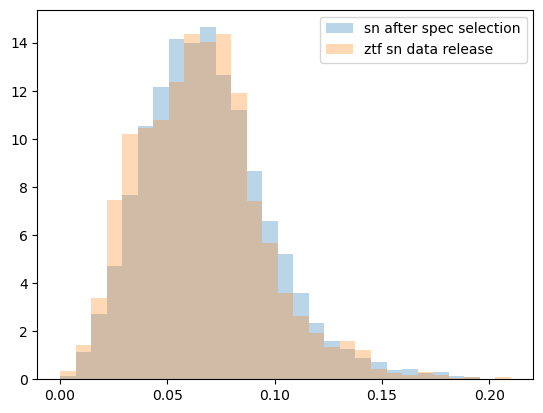

<Figure size 640x480 with 0 Axes>

In [15]:
bins=np.linspace(0,0.21,30)
# plt.hist(lightcurves['z'],bins=bins,alpha=0.3,density=True,label='all sn')
# plt.hist(lightcurves_after_detection['z'],bins=bins,alpha=0.3,density=True,label='sn after detection')
plt.hist(lightcurves_after_spec_selection['z'],bins=bins,alpha=0.3,density=True,label='sn after spec selection')
plt.hist(data.redshift,bins=bins,alpha=0.3,density=True,label='ztf sn data release')
plt.legend()
plt.show()
plt.savefig('paper_figs/z_distr.png')

In [16]:
# data quality flags

# from https://github.com/ZwickyTransientFacility/ztfcosmo/blob/260e136be064708e1238719880ce18844027422e/ztfcosmo/lightcurve.py#L111
# flagout: [list of int or string]
#     flag == 0 means all good, but may not be detected:
    
#     0: no warning 
#     1: flux_err==0 Remove unphysical errors 
#     2: chi2dof>3: Remove extreme outliers 
#     4: cloudy>1: BTS cut 
#     8: infobits>0: BTS cut 
#     16: mag_lim<19.3: Cut applied in Dhawan 2021 
#     32: seeing>3: Cut applied in Dhawan 2021 
#     64: fieldid>879: Recommended IPAC cut 
#     128: moonilf>0.5: Recommended IPAC cut 
#     256: has_baseline>1: Has a valid baseline correction 
#     512: airmass>2: Recommended IPAC cut 
#     1024: flux/flux_err>=5: Nominal detection

In [17]:
# ztf sndr2 flags
# sn_type SNIa classification 
# sub_type sub classification if any. 
# lccoverage_flag passes the good sampling cut (bool,Table1) 
# fitquality_flag passes all other Basic cuts (bool,Table1)

In [18]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

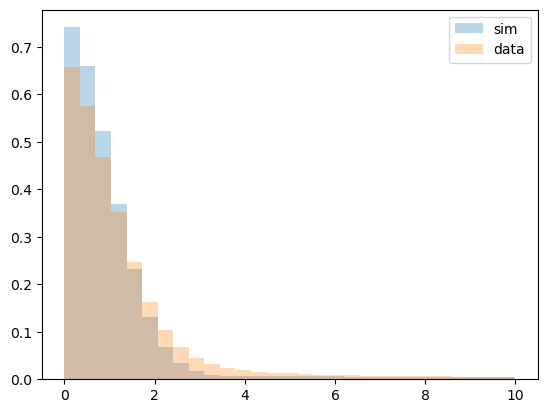

In [19]:
lc_to_plot = lightcurves.loc[lightcurves_after_spec_selection.index]
lcdata_plot = lcdata
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']

bins = np.linspace(0,10,30)

plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,alpha=0.3,density=True,labels=['sim','data'])

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


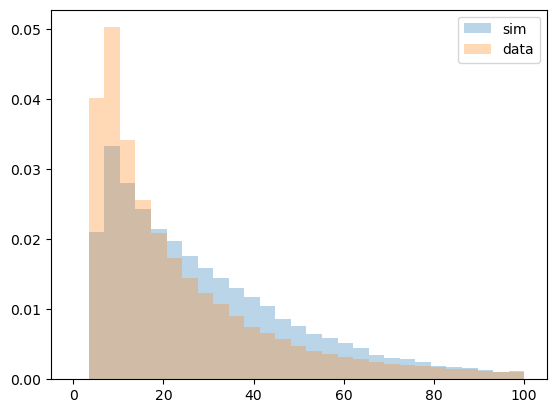

In [20]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata["lc.pass_flag_filter"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32,64,128,256,512],flags_to_include=[1024])
lcdata_plot = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query("lc.snr > 5").dropna(subset="lc")

bins = np.linspace(0,100,30)

plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,alpha=0.3,density=True,labels=['sim','data'])

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


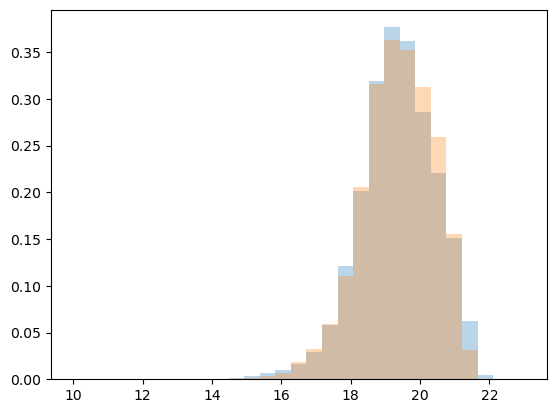

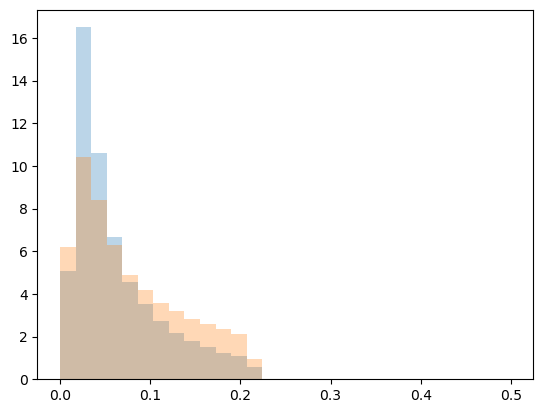

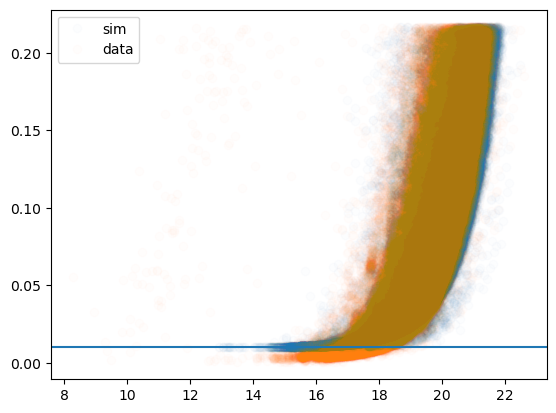

In [77]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query("lc.snr > 5").dropna(subset="lc")

lc_to_plot['lc.mag'],lc_to_plot['lc.magerr'] = convert_flux_to_mag(lc_to_plot['lc.flux'],lc_to_plot['lc.fluxerr'],zp=31.4)
lcdata_plot['lc.mag'],lcdata_plot['lc.magerr'] = convert_flux_to_mag(lcdata_plot['lc.flux'],lcdata_plot['lc.flux_err'],zp=30.)

plot_mag_vs_magerr(lc_to_plot,lcdata_plot)

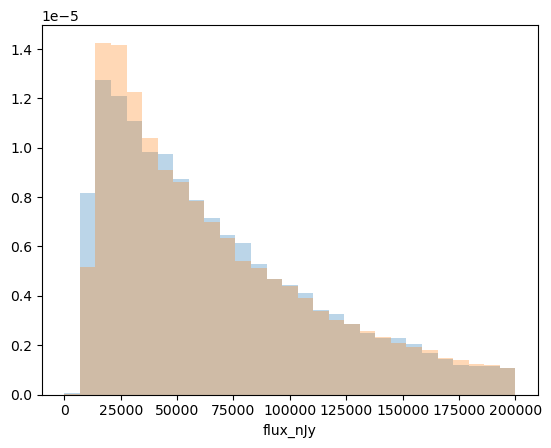

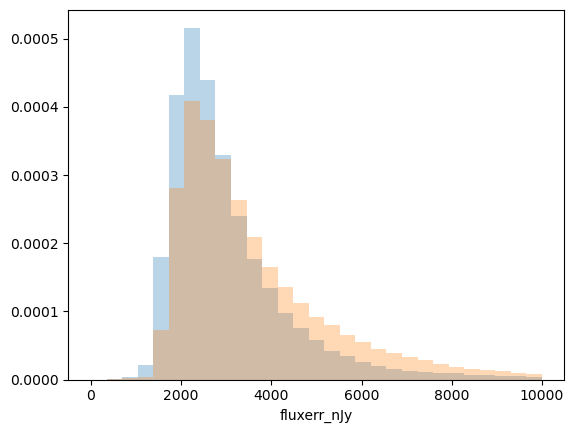

<string>:23: UserWarning: The following kwargs were not used by contour: 'label'
<string>:24: UserWarning: The following kwargs were not used by contour: 'label'


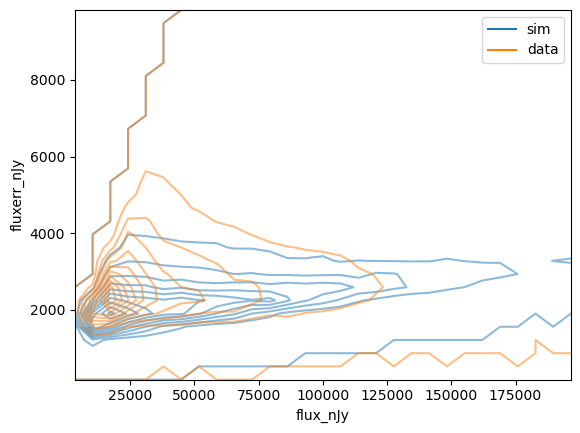

In [76]:
plot_flux_vs_fluxerr(lc_to_plot,lcdata_plot)

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


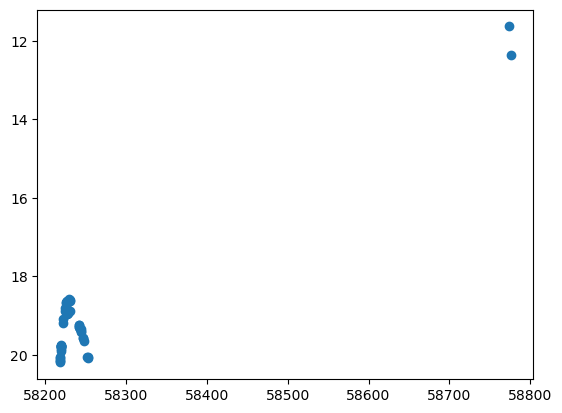

ZTF18aajtlbf
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58218.39372   ztfr  3.458000e+04  1.018217e+03  30.0  1024  18.652938   
1   58218.41253   ztfr  3.036280e+04  9.915986e+02  30.0  1024  18.794145   
..          ...    ...           ...           ...   ...   ...        ...   
51  58774.16889   ztfg  8.057513e+07  4.528020e+06  30.0  1024  10.234497   
52  58776.16822   ztfg  4.172661e+07  4.416115e+06  30.0  1024  10.948967   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.03197       825   4.0 -22932.44373   121.05652    1.00000            0   
1   0.03546       825   4.0 -22932.44373   121.05652    1.00000            0   
..      ...       ...   ...          ...         ...        ...          ...   
51  0.06101       825   4.0 -88257.33529   170.00644    1.67902            0   
52  0.11491       825   4.0 -88257.33529   170.00644    1.67902            0   

          snr  pass_flag_filter    magerr  

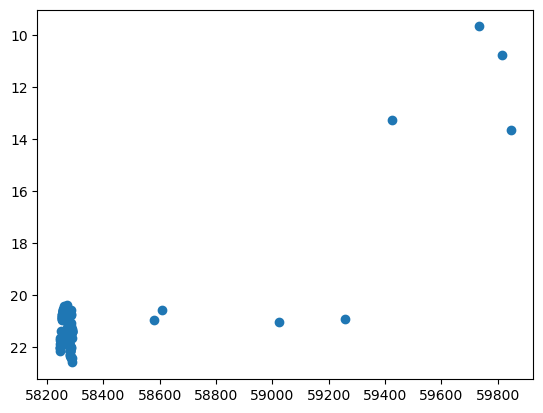

ZTF18aashtth
             mjd filter          flux      flux_err    ZP  flag        mag  \
0    58246.33757   ztfg  5.008439e+03  8.449795e+02  30.0  1024  20.750744   
1    58246.36031   ztfg  5.797578e+03  7.928762e+02  30.0  1024  20.591883   
..           ...    ...           ...           ...   ...   ...        ...   
134  59816.20694   ztfg  1.796189e+08  1.232231e+06  30.0  1024   9.364120   
135  59847.16666   ztfg  1.267507e+07  1.602516e+06  30.0  1024  12.242624   

     mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0    0.18318       635  32.0    167.23896    43.98385        1.0            0   
1    0.14849       635  32.0    167.23896    43.98385        1.0            0   
..       ...       ...   ...          ...         ...        ...          ...   
134  0.00745       635  32.0    167.23896    43.98385        1.0            0   
135  0.13727       635  32.0    167.23896    43.98385        1.0            0   

            snr  pass_flag_filt

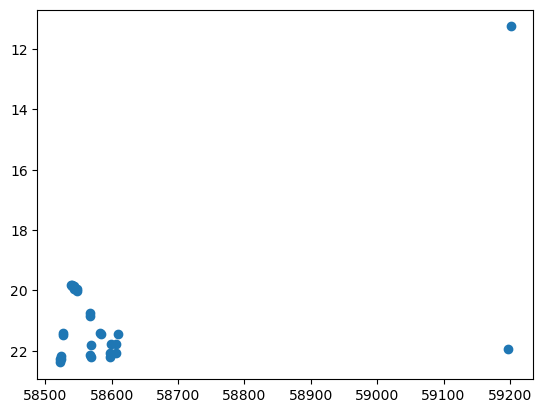

ZTF19aaklbok
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58522.17616   ztfg  4.520296e+03  6.676605e+02  30.0  1024  20.862083   
1   58522.22370   ztfr  4.022425e+03  7.573167e+02  30.0  1024  20.988780   
2   58523.22231   ztfr  4.524846e+03  7.878103e+02  30.0  1024  20.860990   
3   58523.23689   ztfg  4.977719e+03  5.510181e+02  30.0  1024  20.757424   
4   58526.21330   ztfr  9.763384e+03  1.150711e+03  30.0  1024  20.025999   
5   58526.22273   ztfr  9.419465e+03  1.195053e+03  30.0  1024  20.064934   
6   58539.22312   ztfg  4.223750e+04  8.455664e+02  30.0  1024  18.435754   
7   58540.18023   ztfg  4.138844e+04  5.709998e+02  30.0  1024  18.457802   
8   58540.20069   ztfr  4.227804e+04  8.471977e+02  30.0  1024  18.434713   
9   58543.23853   ztfr  4.129976e+04  1.185444e+03  30.0  1024  18.460131   
10  58543.23953   ztfr  3.747957e+04  1.232862e+03  30.0  1024  18.565514   
11  58547.18644   ztfr  3.835374e+04  8.135974e+02  30.0  1024 

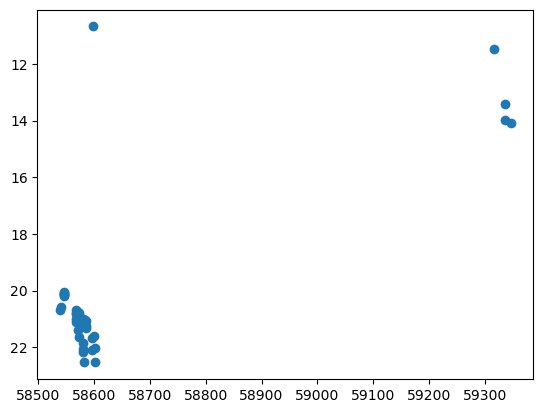

ZTF19aaksrgj
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58539.35573   ztfr  1.921365e+04  1.685139e+03  30.0  1024  19.290976   
1   58540.35671   ztfg  2.152612e+04  7.051787e+02  30.0  1024  19.167586   
..          ...    ...           ...           ...   ...   ...        ...   
39  59335.23204   ztfg  9.258658e+06  1.584806e+06  30.0  1024  12.583630   
40  59346.31597   ztfg  8.449574e+06  1.602285e+06  30.0  1024  12.682913   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.09522       474  60.0   1029.44408   139.55419        1.0            0   
1   0.03557       525   2.0     22.28824    62.57741        1.0            0   
..      ...       ...   ...          ...         ...        ...          ...   
39  0.18585       525   2.0     22.28824    62.57741        1.0            0   
40  0.20589       525   2.0     22.28824    62.57741        1.0            0   

          snr  pass_flag_filter    magerr  

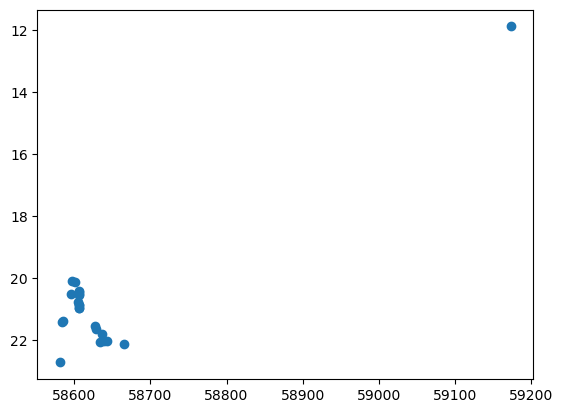

ZTF19aapwbvm
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58581.35597   ztfg  2.941383e+03  4.215684e+02  30.0  1024  21.328621   
1   58584.43975   ztfr  9.849912e+03  6.035988e+02  30.0  1024  20.016419   
2   58585.43250   ztfr  1.017408e+04  1.317373e+03  30.0  1024  19.981262   
3   58596.39169   ztfi  2.264491e+04  1.980974e+03  30.0  1024  19.112574   
4   58597.40727   ztfr  3.276003e+04  1.275121e+03  30.0  1024  18.711639   
5   58600.47657   ztfr  3.204426e+04  9.456735e+02  30.0  1024  18.735624   
6   58605.47856   ztfi  1.786639e+04  1.818061e+03  30.0  1024  19.369908   
7   58606.32417   ztfr  2.247034e+04  1.228119e+03  30.0  1024  19.120976   
8   58606.32608   ztfr  2.215548e+04  1.370770e+03  30.0  1024  19.136297   
9   58606.35172   ztfr  2.426198e+04  1.102775e+03  30.0  1024  19.037684   
10  58606.37147   ztfr  2.478052e+04  1.090474e+03  30.0  1024  19.014724   
11  58606.44367   ztfg  1.505557e+04  5.211769e+02  30.0  1024 

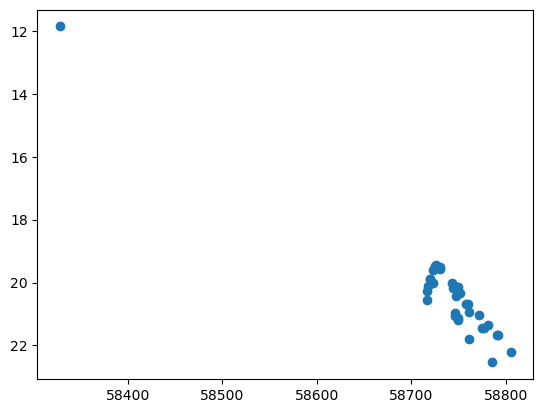

ZTF19abqviuy
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58328.43756   ztfr  6.603333e+07  4.331535e+06  30.0  1024  10.450592   
1   58716.32503   ztfi  2.160467e+04  1.977578e+03  30.0  1024  19.163631   
..          ...    ...           ...           ...   ...   ...        ...   
36  58791.34272   ztfr  7.795143e+03  1.034769e+03  30.0  1024  20.270440   
37  58805.21142   ztfr  4.773348e+03  8.977833e+02  30.0  1024  20.802942   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.07122       447  40.0    -11.46083   150.68536        1.0            0   
1   0.09938       447  40.0   -463.32931   136.20113        1.0            0   
..      ...       ...   ...          ...         ...        ...          ...   
36  0.14413       447  40.0    -11.46083   150.68536        1.0            0   
37  0.20421       447  40.0    -11.46083   150.68536        1.0            0   

          snr  pass_flag_filter    magerr  

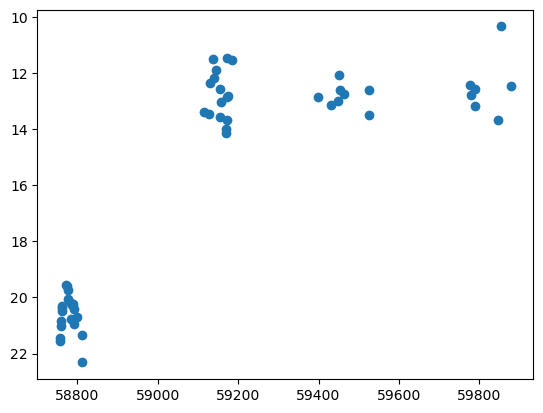

ZTF19accmxtw
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58757.26645   ztfi  9.443234e+03  1.312251e+03  30.0  1024  20.062198   
1   58758.21080   ztfg  8.818193e+03  6.746138e+02  30.0  1024  20.136551   
..          ...    ...           ...           ...   ...   ...        ...   
49  59854.30641   ztfr  2.638430e+08  7.961178e+06  30.0  1024   8.946636   
50  59878.13013   ztfr  3.765777e+07  1.394651e+06  30.0  1024  11.060363   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.15088       597  29.0   -326.73539   225.93636    1.19402            0   
1   0.08306       597  29.0     81.34453    53.43814    1.00000            0   
..      ...       ...   ...          ...         ...        ...          ...   
49  0.03276       597  29.0   -406.89933    81.82750    1.16814            0   
50  0.04021       597  29.0   -406.89933    81.82750    1.16814            0   

          snr  pass_flag_filter    magerr  

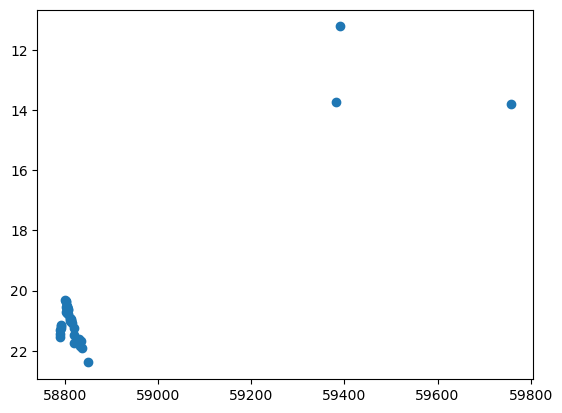

ZTF19aclthzj
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58789.26551   ztfr  9.457304e+03  1.027669e+03  30.0  1024  20.060582   
1   58789.36226   ztfg  8.733596e+03  7.534137e+02  30.0  1024  20.147017   
..          ...    ...           ...           ...   ...   ...        ...   
37  59390.46450   ztfr  1.184480e+08  2.202085e+06  30.0  1024   9.816181   
38  59757.46943   ztfg  1.116158e+07  6.395750e+05  30.0  1024  12.380686   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.11798       698  15.0    239.92064    54.40362        1.0            0   
1   0.09366       698  15.0   -183.28552    67.01241        1.0            0   
..      ...       ...   ...          ...         ...        ...          ...   
37  0.02019       698  15.0    239.92064    54.40362        1.0            0   
38  0.06221       698  15.0   -183.28552    67.01241        1.0            0   

          snr  pass_flag_filter    magerr  

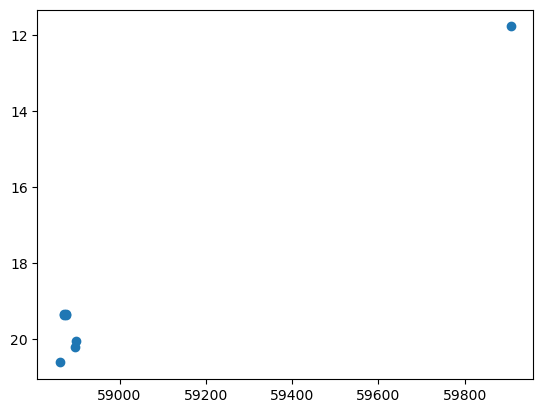

ZTF20aafdeza
           mjd filter          flux      flux_err    ZP  flag        mag  \
0  58862.11102   ztfg  2.045175e+04  1.050193e+03  30.0  1024  19.223174   
1  58872.11706   ztfr  6.579368e+04  1.495185e+03  30.0  1024  17.954540   
2  58872.16275   ztfg  6.514351e+04  1.986324e+03  30.0  1024  17.965322   
3  58875.10900   ztfr  6.601988e+04  1.346020e+03  30.0  1024  17.950813   
4  58875.13443   ztfg  6.507560e+04  1.485678e+03  30.0  1024  17.966454   
5  58896.11177   ztfr  2.948360e+04  1.914472e+03  30.0  1024  18.826049   
6  58898.10628   ztfr  3.403979e+04  2.845181e+03  30.0  1024  18.670033   
7  59907.15023   ztfr  7.024443e+07  1.645347e+06  30.0  1024  10.383470   

   mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0  0.05575       600  21.0   1348.57351   158.12187    1.54008            0   
1  0.02467       600  21.0   1340.18592    86.51856    1.31652            0   
2  0.03311       600  21.0   1348.57351   158.12187    1.54008   

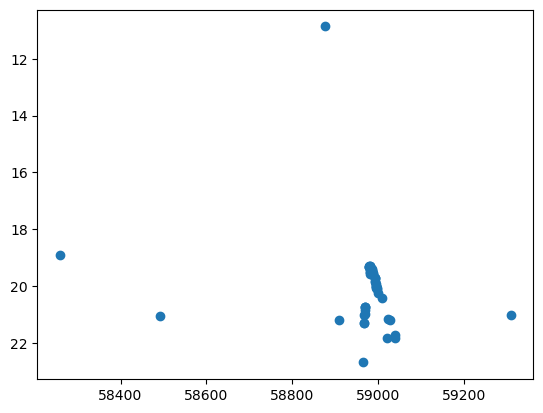

ZTF20aaxahpk
            mjd filter         flux     flux_err    ZP  flag        mag  \
0   58259.17374   ztfg  98462.52214  19616.43048  30.0  1024  17.516823   
1   58492.48949   ztfr  13727.88280   2446.91805  30.0  1024  19.655991   
..          ...    ...          ...          ...   ...   ...        ...   
46  59038.17892   ztfr   7387.45796   1025.23483  30.0  1024  20.328762   
47  59308.34090   ztfg  14125.28312   2308.68883  30.0  1024  19.625007   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.21631       713  33.0    255.41977   122.83969    1.03982            0   
1   0.19353       713  33.0   -128.40675    56.83178    1.04531            0   
..      ...       ...   ...          ...         ...        ...          ...   
46  0.15068       713  33.0   -128.40675    56.83178    1.04531            0   
47  0.17746       713  33.0    255.41977   122.83969    1.03982            0   

         snr  pass_flag_filter    magerr  
0   5.019390

In [22]:
# check about the outliers in data
maglim = mag2flux(12)
idx = lcdata_plot.query(f'lc.flux > {maglim}').dropna(subset='lc').index
outlier = lcdata_plot.loc[idx]
for i in range(0,np.min([10,len(outlier)])):
    plt.plot(outlier.iloc[i]['lc']['mjd'],flux2mag(outlier.iloc[i]['lc']['flux']),'o')
    plt.ylim(plt.ylim()[::-1])
    plt.show()
    print(outlier.iloc[i]['ztfname'])
    print(outlier.iloc[i]['lc'])

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


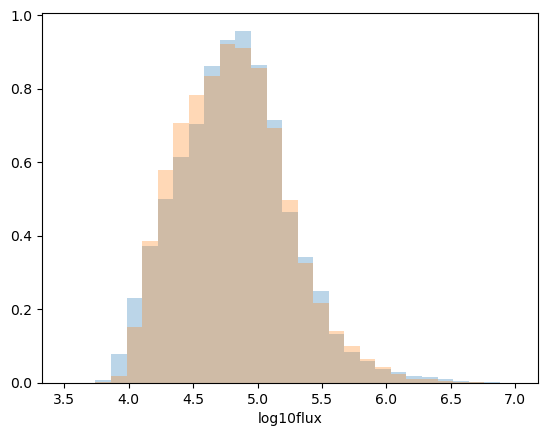

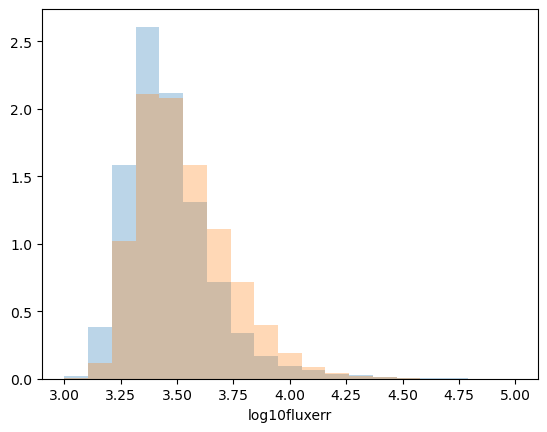

/Users/mi/Work/lightcurvelynx_ztf_sim/utils/plotting_utils.py:59: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
/Users/mi/Work/lightcurvelynx_ztf_sim/utils/plotting_utils.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')


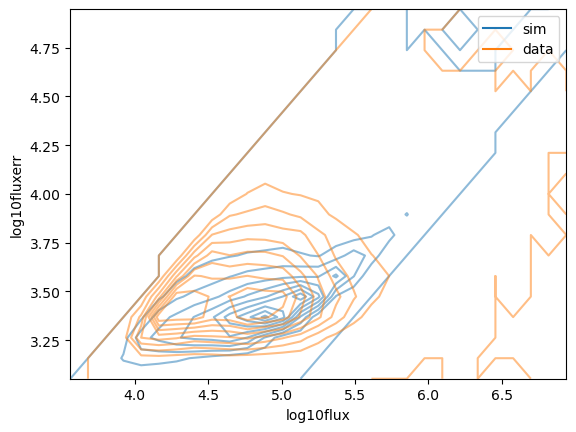

In [23]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query("lc.snr > 5").dropna(subset="lc")

plot_logflux_vs_logfluxerr(lc_to_plot, lcdata_plot)

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


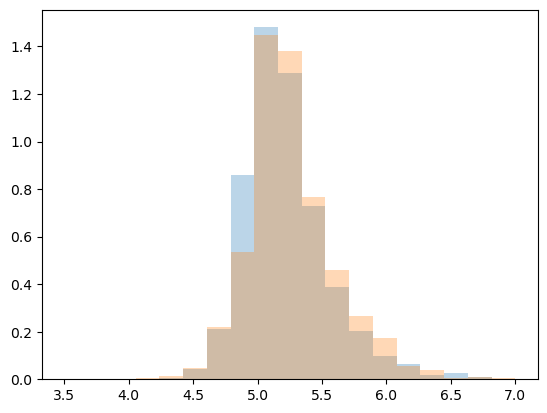

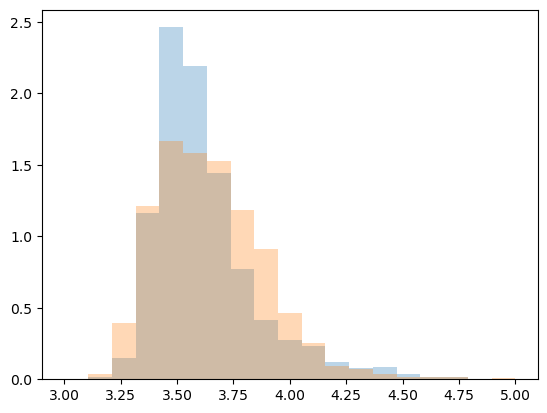

/Users/mi/Work/lightcurvelynx_ztf_sim/utils/plotting_utils.py:114: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
/Users/mi/Work/lightcurvelynx_ztf_sim/utils/plotting_utils.py:115: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')


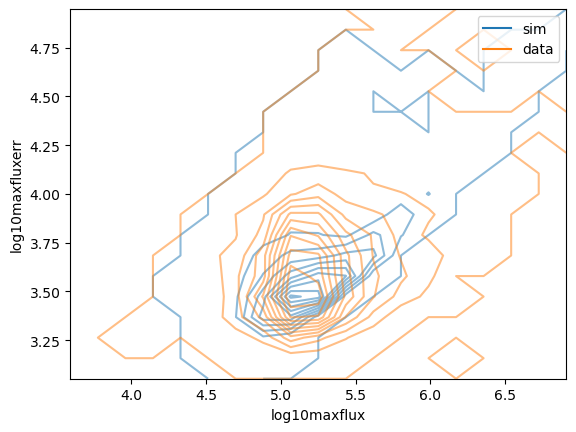

In [24]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query("lc.snr > 5").dropna(subset="lc")

plot_logmaxflux_vs_logmaxfluxerr(lc_to_plot,lcdata_plot)

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:645: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


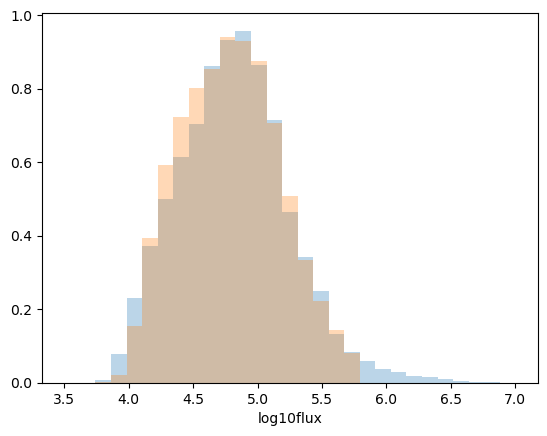

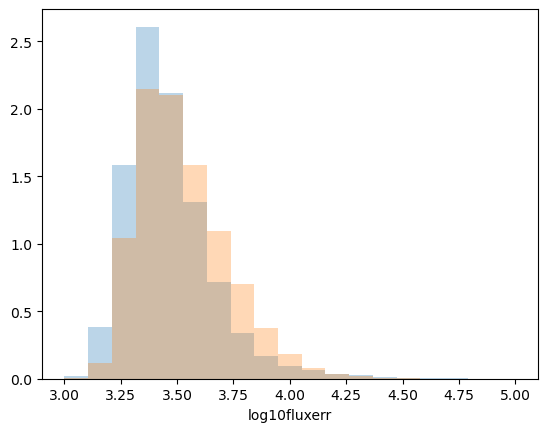

/Users/mi/Work/lightcurvelynx_ztf_sim/utils/plotting_utils.py:59: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcsim_x_plot.T,lcsim_y_plot.T,lcsim_count,alpha=0.5,label='sim',levels=10,colors='C0')
/Users/mi/Work/lightcurvelynx_ztf_sim/utils/plotting_utils.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  CS = plt.contour(lcdata_x_plot.T,lcdata_y_plot.T,lcdata_count,alpha=0.5,label='data',levels=10,colors='C1')


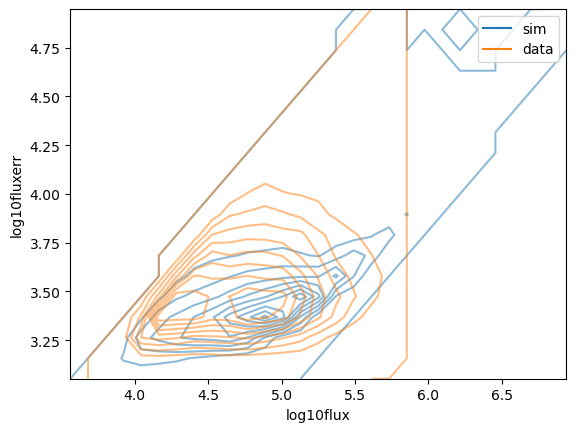

In [52]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
lcdata_plot['lc.snr'] = lcdata_plot['lc.flux']/lcdata_plot['lc.flux_err']
lcdata_plot = lcdata_plot.query("lc.snr > 5").dropna(subset="lc")

lcdata_plot['lc.mag'],_ = convert_flux_to_mag(lcdata_plot['lc.flux'],lcdata_plot['lc.flux_err'],zp=30.)

lcdata_plot = lcdata_plot.query("lc.mag > 17").dropna(subset="lc")

plot_logflux_vs_logfluxerr(lc_to_plot, lcdata_plot)

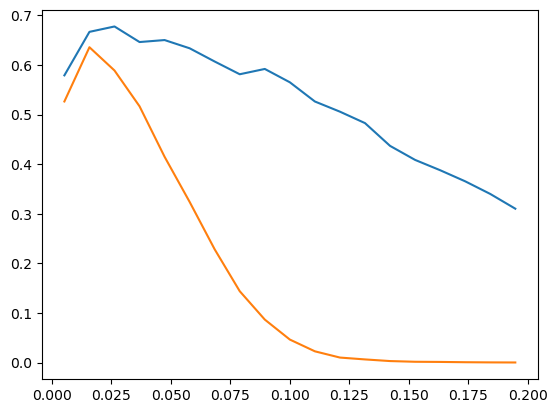

In [26]:
bins = np.linspace(0,0.2,20)
zbefore,bin_edges,_ = stats.binned_statistic(lightcurves['z'],np.ones(len(lightcurves)), statistic='sum', bins=bins)
zafter,bin_edges,_ =  stats.binned_statistic(lightcurves_after_detection['z'], np.ones(len(lightcurves_after_detection)), statistic='sum', bins=bins)
zafter_spec,bin_edges,_ =  stats.binned_statistic(lightcurves_after_spec_selection['z'], np.ones(len(lightcurves_after_spec_selection)), statistic='sum', bins=bins)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,zafter/zbefore)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,zafter_spec/zbefore)

In [27]:
sim_all_x1 = [lightcurves.loc[i]['params']['source.x1'] for i in lightcurves.index]
sim_all_c = [lightcurves.loc[i]['params']['source.c'] for i in lightcurves.index]

In [28]:
sim_x1 = [lightcurves_after_quality_cut.loc[i]['params']['source.x1'] for i in lightcurves_after_quality_cut.index]
sim_c = [lightcurves_after_quality_cut.loc[i]['params']['source.c'] for i in lightcurves_after_quality_cut.index]

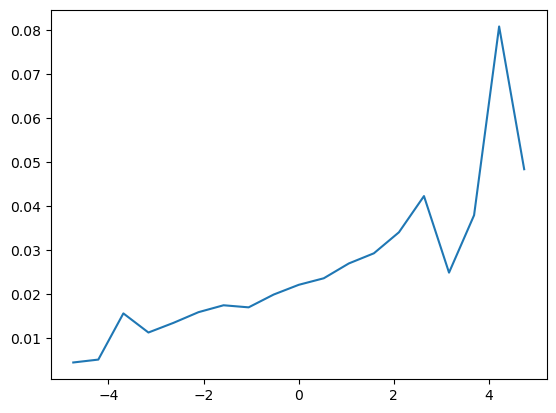

In [29]:
bins = np.linspace(-5,5,20)
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before)
plt.savefig('paper_figs/x1_selection.png')

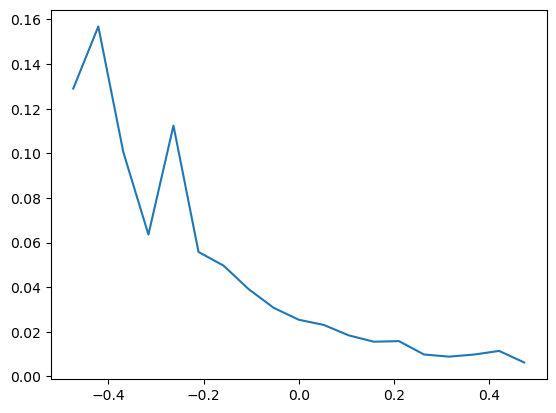

In [30]:
bins = np.linspace(-0.5,0.5,20)
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
plt.plot((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore)
plt.savefig('paper_figs/c_selection.png')

Text(0.5, 1.0, 'reduced chisq')

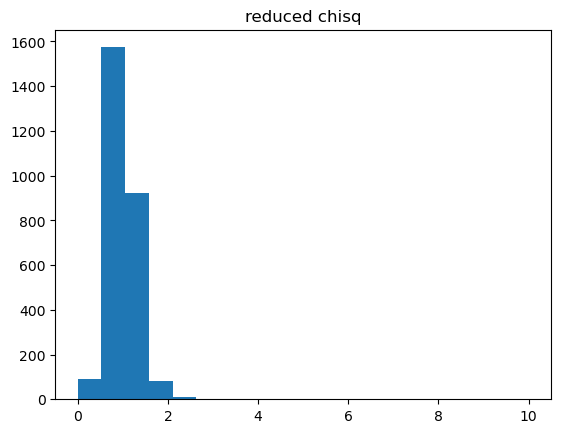

In [31]:
result_df = saltpars
idx = result_df.ndof > 0
result_df = result_df[idx]
plt.hist(result_df[idx].chisq/result_df[idx].ndof,bins=np.linspace(0,10,20))
plt.title('reduced chisq')

In [32]:
lc_to_fit = lightcurves

Text(0.5, 1.0, 'x1-sim_x1')

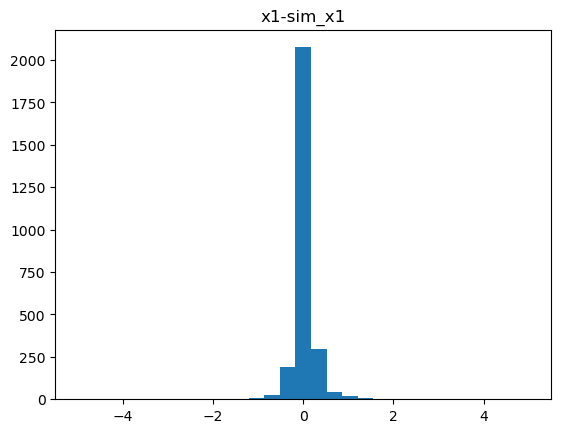

In [33]:
x1 = result_df['x1']
sim_x1 = [lc_to_fit.loc[i]['params']['source.x1'] for i in result_df.id]
plt.hist(x1-sim_x1,bins=np.linspace(-5,5,30))
plt.title('x1-sim_x1')

Text(0.5, 1.0, 'c-sim_c')

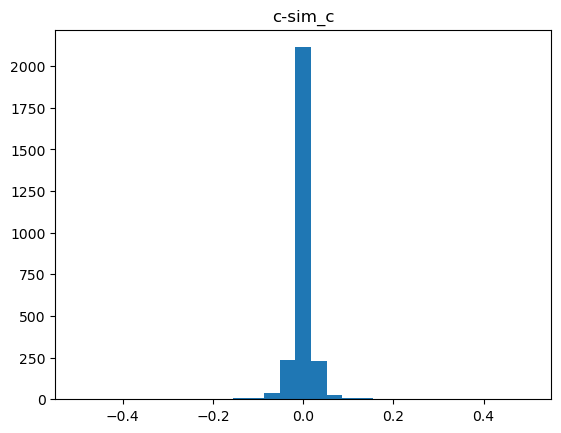

In [34]:
c = result_df['c']
sim_c = [lc_to_fit.loc[i]['params']['source.c'] for i in result_df.id]
plt.hist(c-sim_c,bins=np.linspace(-0.5,0.5,30))
plt.title('c-sim_c')

Text(0.5, 1.0, 'x0-sim_x0')

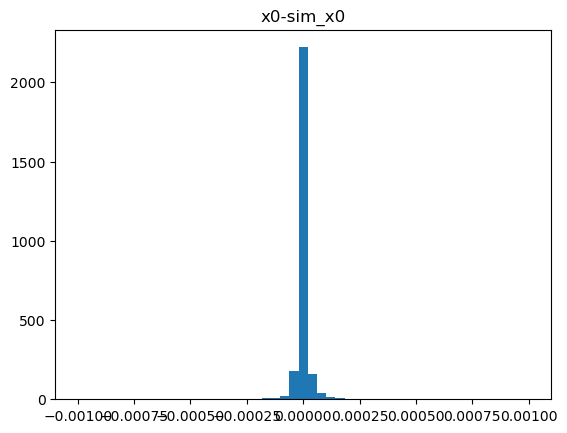

In [35]:
x0 = result_df['x0']
sim_x0 = [lc_to_fit.loc[i]['params']['source.x0'] for i in result_df.id]
plt.hist(x0-sim_x0,bins=np.linspace(-1.e-3,1.e-3))
plt.title('x0-sim_x0')

Text(0.5, 1.0, 'log(x0)-log(sim_x0)')

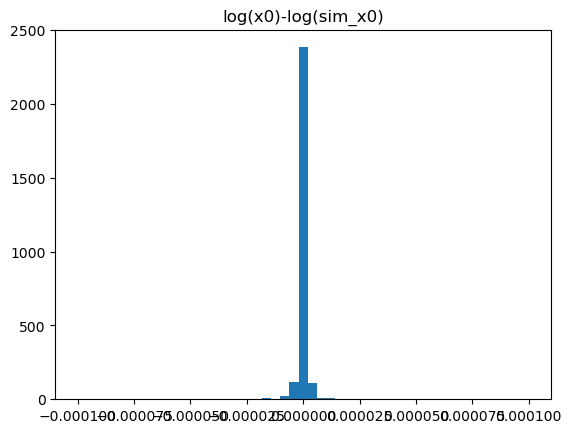

In [36]:
x0 = result_df['t0']
sim_x0 = [lc_to_fit.loc[i]['params']['source.t0'] for i in result_df.id]
plt.hist(np.log10(x0/sim_x0),bins=np.linspace(-1.e-4,1e-4))
plt.title('log(x0)-log(sim_x0)')

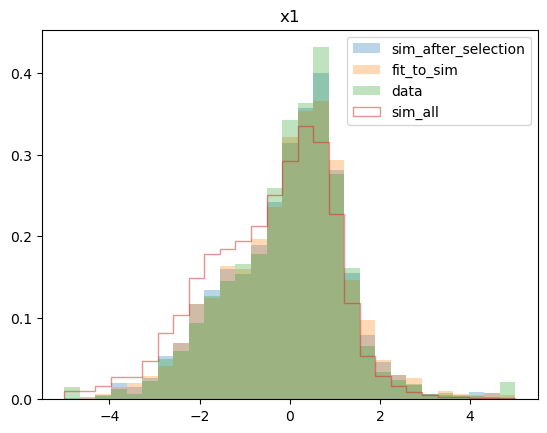

In [37]:
bins=np.linspace(-5,5,30)
plt.hist(sim_x1,bins=bins,alpha=0.3,density=True,label='sim_after_selection')
plt.hist(x1,bins=bins,alpha=0.3,density=True,label='fit_to_sim')
plt.hist(data.x1,bins=bins,alpha=0.3,density=True,label='data')
plt.hist(sim_all_x1,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('x1')
plt.savefig('paper_figs/x1_distr.png')

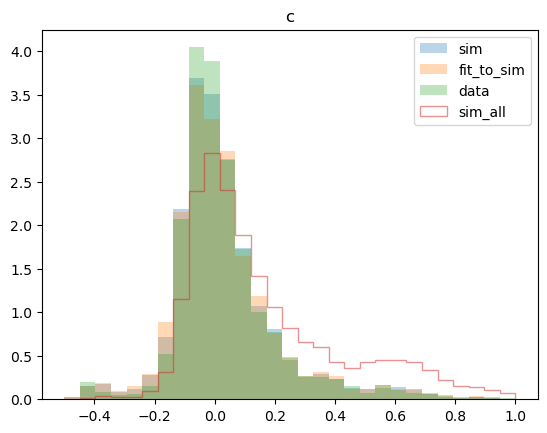

In [38]:
bins=np.linspace(-0.5,1,30)
plt.hist(sim_c,bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(c,bins=bins,alpha=0.3,density=True,label='fit_to_sim')
plt.hist(data.c,bins=bins,alpha=0.3,density=True,label='data')
plt.hist(sim_all_c,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('c')
plt.savefig('paper_figs/c_distr.png')

Text(0.5, 1.0, 'x1')

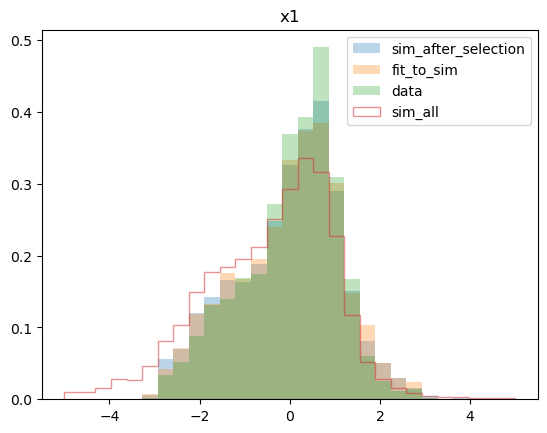

In [39]:
bins=np.linspace(-5,5,30)
plt.hist(np.array(sim_x1)[saltpar_cuts],bins=bins,alpha=0.3,density=True,label='sim_after_selection')
plt.hist(x1.loc[saltpar_cuts],bins=bins,alpha=0.3,density=True,label='fit_to_sim')
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True)
plt.hist(data.loc[data_idx, "x1"],bins=bins,alpha=0.3,density=True,label='data')
plt.hist(sim_all_x1,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('x1')
# plt.savefig('paper_figs/x1_distr.png')

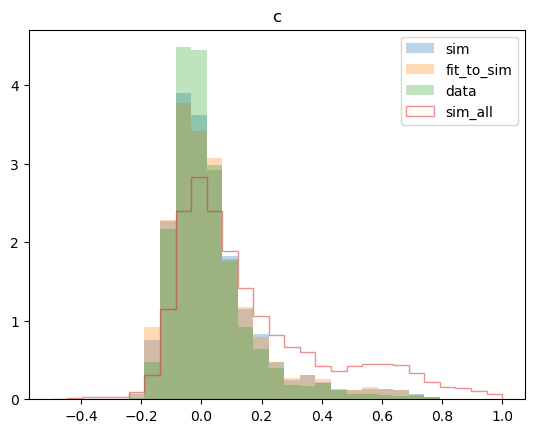

In [40]:
bins=np.linspace(-0.5,1,30)
plt.hist(np.array(sim_c)[saltpar_cuts],bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(c.loc[saltpar_cuts],bins=bins,alpha=0.3,density=True,label='fit_to_sim')
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True)
plt.hist(data.loc[data_idx,"c"],bins=bins,alpha=0.3,density=True,label='data')
plt.hist(sim_all_c,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('c')
plt.savefig('paper_figs/c_distr.png')

Text(0.5, 1.0, 'host mass')

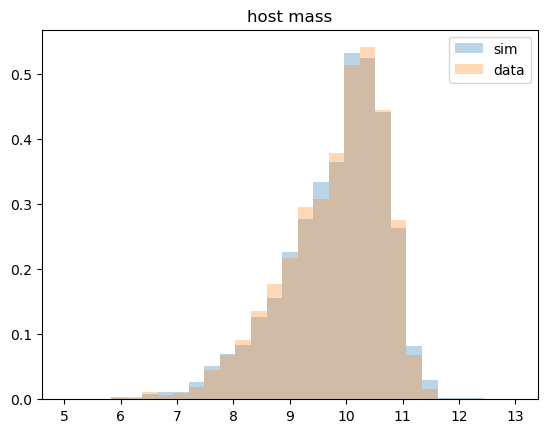

In [41]:
hostmass = [lc_to_fit.loc[i]['params']['host.hostmass'] for i in result_df.id]
bins = np.linspace(5,13,30)
plt.hist(hostmass,bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(data.mass,bins=bins,alpha=0.3,density=True,label='data')
plt.legend()
plt.title('host mass')

2400
2666


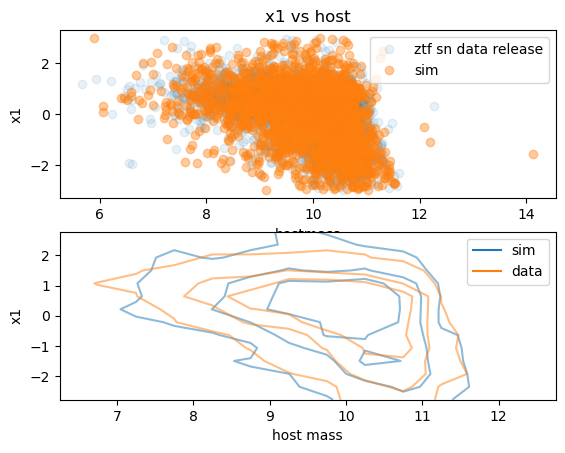

In [42]:
idx = saltpar_cuts
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True)
print(np.sum(idx))
print(np.sum(data_idx))

fig = plt.figure()
plt.subplot(2,1,1)
plt.plot(data[data_idx].mass,data[data_idx].x1,'o',label='ztf sn data release',alpha=0.1)
plt.plot(np.array(hostmass)[idx],np.array(x1)[idx],'o',label='sim',alpha=0.4)
plt.xlabel('hostmass')
plt.ylabel('x1')
plt.legend()
plt.title('x1 vs host')
# plt.show()

plt.subplot(2,1,2)
bins_x1 = np.linspace(-3,3,15)
bins_hostmass = np.linspace(6,13,15)

data_plot = data[data_idx]
sim_host = np.array(hostmass)[idx]
sim_x1 = np.array(x1)[idx]

binwidth_host = bins_hostmass[1]-bins_hostmass[0]
binwidth_x1 = bins_x1[1]-bins_x1[0]

sim_count,sim_x_edges,sim_y_edges, _ = stats.binned_statistic_2d(sim_host,sim_x1,
                                             np.ones(len(sim_host)),
                                             statistic='sum',bins=[bins_hostmass,bins_x1])
data_count,data_x_edges,data_y_edges,_ = stats.binned_statistic_2d(data_plot.mass,data_plot.x1,
                                         np.ones(len(data_plot.mass)),
                                         statistic='sum',bins=[bins_hostmass,bins_x1])
sim_x = 0.5* (sim_x_edges[:-1]+sim_x_edges[1:])
sim_y = 0.5* (sim_y_edges[:-1]+sim_y_edges[1:])
data_x = 0.5* (data_x_edges[:-1]+data_x_edges[1:])
data_y = 0.5* (data_y_edges[:-1]+data_y_edges[1:])
sim_x_plot,sim_y_plot = np.meshgrid(sim_x, sim_y)
data_x_plot,data_y_plot = np.meshgrid(data_x, data_y)
CS = plt.contour(sim_x_plot.T,sim_y_plot.T,sim_count/np.sum(sim_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='C0')
CS = plt.contour(data_x_plot.T,data_y_plot.T,data_count/np.sum(data_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='C1')
proxies = [Line2D([],[],color=c) for c in ['C0','C1']]
plt.legend(proxies,['sim', 'data'])
plt.xlabel('host mass')
plt.ylabel('x1')
plt.show()
fig.savefig('paper_figs/host_x1.png')

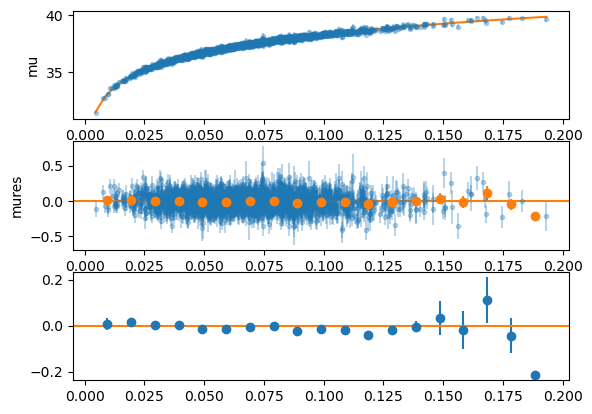

In [43]:
# make HD

x1_hd = result_df.loc[saltpar_cuts,"x1"]
c_hd = result_df.loc[saltpar_cuts,"c"]
x0_hd = result_df.loc[saltpar_cuts,"x0"]
z_hd = result_df.loc[saltpar_cuts,"z"]

x1_err = result_df.loc[saltpar_cuts,"x1_err"]
c_err = result_df.loc[saltpar_cuts,"c_err"]
x0_err = result_df.loc[saltpar_cuts,"x0_err"]

mb_hd = -2.5*np.log10(x0_hd) + 10.635
mb_err = 2.5/np.log(10) * (x0_err/x0_hd)

alpha = 0.14
beta = 3.1
Mb = -19.05
mu_hd = mb_hd + alpha*x1_hd - beta*c_hd - Mb
mu_err = np.sqrt(mb_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + 0.1**2)

ax1 = plt.subplot(3,1,1)

ax1.errorbar(z_hd, mu_hd, yerr=mu_err,fmt='.',alpha=0.3)

z_cosmo = np.linspace(z_hd.min(),z_hd.max(),50)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_cosmo = cosmo.distmod(z_cosmo)
ax1.plot(z_cosmo, mu_cosmo)

plt.xlabel('z')
plt.ylabel('mu')

mures = mu_hd - cosmo.distmod(z_hd).value

ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.errorbar(z_hd, mures, yerr=mu_err, fmt='.',alpha=0.3)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax2.axhline(y=0,color=colors[1])
plt.ylabel('mures')

bins= np.linspace(z_hd.min(),z_hd.max(),20)
mures_mean, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='mean', bins= bins
)

mures_std, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='std', bins= bins
)

mures_count, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='count', bins= bins
) 

mures_err = mures_std / np.sqrt(mures_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
ax2.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')

ax3 = plt.subplot(3,1,3, sharex=ax1)
ax3.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')
ax3.axhline(y=0,color=colors[1])

(0.0, 0.2)

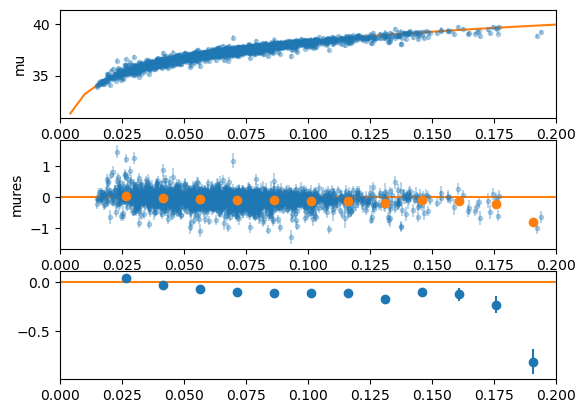

In [44]:
# make HD

data_x1_hd = data[data_idx].x1
data_c_hd = data[data_idx].c
data_x0_hd = data[data_idx].x0
data_z_hd = data[data_idx].redshift

data_x1_err = data[data_idx].x1_err
data_c_err = data[data_idx].c_err
data_x0_err = data[data_idx].x0_err

data_mb_hd = -2.5*np.log10(data_x0_hd) + 10.635
data_mb_err = 2.5/np.log(10) * (data_x0_err/data_x0_hd)

alpha = 0.14
beta = 3.1
Mb = -19.05
data_mu_hd = data_mb_hd + alpha*data_x1_hd - beta*data_c_hd - Mb
data_mu_err = np.sqrt(data_mb_err**2 + alpha**2*data_x1_err**2 + beta**2*data_c_err**2 + 0.1**2)

ax1 = plt.subplot(3,1,1)

ax1.errorbar(data_z_hd, data_mu_hd, yerr=data_mu_err,fmt='.',alpha=0.3)

data_z_cosmo = np.linspace(data_z_hd.min(),data_z_hd.max(),50)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
data_mu_cosmo = cosmo.distmod(data_z_cosmo)
ax1.plot(data_z_cosmo, data_mu_cosmo)

plt.xlabel('z')
plt.ylabel('mu')

data_mures = data_mu_hd - cosmo.distmod(data_z_hd).value

ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.errorbar(data_z_hd, data_mures, yerr=data_mu_err, fmt='.',alpha=0.3)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax2.axhline(y=0,color=colors[1])
plt.ylabel('mures')

bins= np.linspace(data_z_hd.min(),data_z_hd.max(),20)
data_mures_mean, bin_edges, _ = stats.binned_statistic(
    data_z_hd, data_mures, statistic='mean', bins= bins
)

data_mures_std, bin_edges, _ = stats.binned_statistic(
    data_z_hd, data_mures, statistic='std', bins= bins
)

data_mures_count, bin_edges, _ = stats.binned_statistic(
    data_z_hd, data_mures, statistic='count', bins= bins
) 

data_mures_err = data_mures_std / np.sqrt(data_mures_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
ax2.errorbar(bin_mean, data_mures_mean, yerr = data_mures_err,fmt='o')

ax3 = plt.subplot(3,1,3, sharex=ax1)
ax3.errorbar(bin_mean, data_mures_mean, yerr = data_mures_err,fmt='o')
ax3.axhline(y=0,color=colors[1])

plt.xlim((0,0.2))

<Axes: >

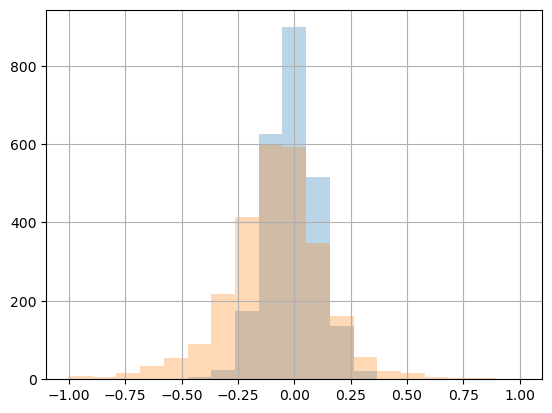

In [45]:
bins = np.linspace(-1,1,20)
mures.hist(bins=bins,alpha=0.3)
data_mures.hist(bins=bins,alpha=0.3)

Text(0, 0.5, 'mures')

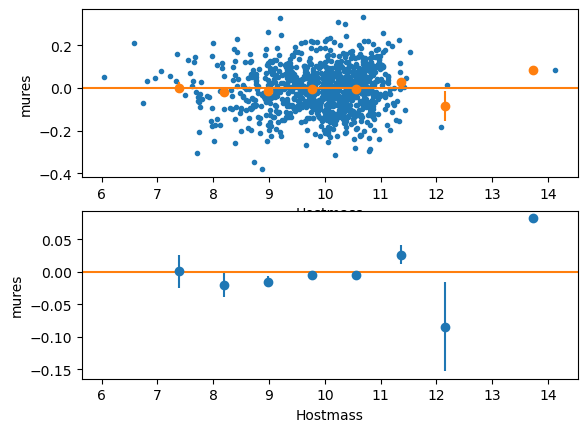

In [46]:
zcut = saltpars["z"]<0.06
hostmass_plot = np.array(hostmass)[saltpar_cuts & zcut]

ax1 = plt.subplot(2,1,1)

ax1.plot(hostmass_plot,mures[zcut],'.')

bins= np.linspace(7,hostmass_plot.max(),10)
hostmass_mean, bin_edges, _ = stats.binned_statistic(
    hostmass_plot, mures[zcut], statistic='mean', bins= bins
)

hostmass_std, bin_edges, _ = stats.binned_statistic(
    hostmass_plot, mures[zcut], statistic='std', bins= bins
)

hostmass_count, bin_edges, _ = stats.binned_statistic(
    hostmass_plot, mures[zcut], statistic='count', bins= bins
) 

hostmass_err = hostmass_std / np.sqrt(hostmass_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
plt.errorbar(bin_mean, hostmass_mean, yerr =hostmass_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('Hostmass')
plt.ylabel('mures')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.errorbar(bin_mean, hostmass_mean, yerr =hostmass_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('Hostmass')
plt.ylabel('mures')

Text(0, 0.5, 'mures')

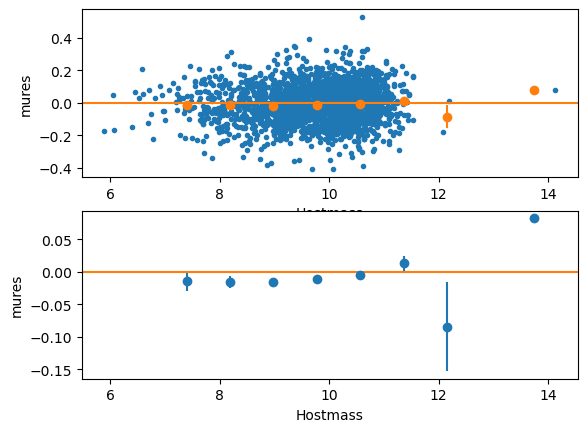

In [47]:
hostmass_plot = np.array(hostmass)[saltpar_cuts]

ax1 = plt.subplot(2,1,1)

ax1.plot(hostmass_plot,mures,'.')

bins= np.linspace(7,hostmass_plot.max(),10)
hostmass_mean, bin_edges, _ = stats.binned_statistic(
    hostmass_plot, mures, statistic='mean', bins= bins
)

hostmass_std, bin_edges, _ = stats.binned_statistic(
    hostmass_plot, mures, statistic='std', bins= bins
)

hostmass_count, bin_edges, _ = stats.binned_statistic(
    hostmass_plot, mures, statistic='count', bins= bins
) 

hostmass_err = hostmass_std / np.sqrt(hostmass_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
plt.errorbar(bin_mean, hostmass_mean, yerr =hostmass_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('Hostmass')
plt.ylabel('mures')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.errorbar(bin_mean, hostmass_mean, yerr =hostmass_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('Hostmass')
plt.ylabel('mures')

Text(0, 0.5, 'mures')

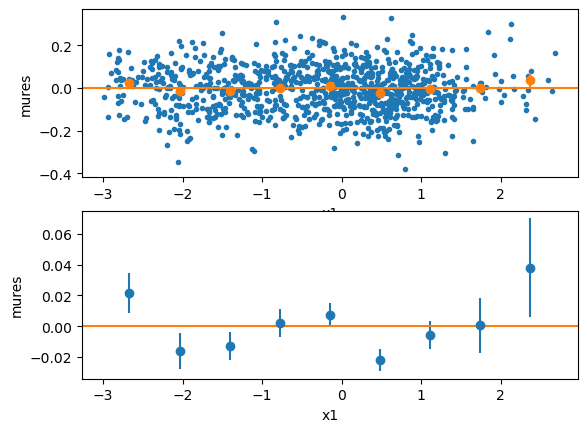

In [48]:
zcut = saltpars["z"]<0.06

x1_plot = np.array(x1)[saltpar_cuts & zcut]

ax1 = plt.subplot(2,1,1)

ax1.plot(x1_plot,mures[zcut],'.')

bins= np.linspace(x1_plot.min(),x1_plot.max(),10)
x1_mean, bin_edges, _ = stats.binned_statistic(
    x1_plot, mures[zcut], statistic='mean', bins= bins
)

x1_std, bin_edges, _ = stats.binned_statistic(
    x1_plot, mures[zcut], statistic='std', bins= bins
)

x1_count, bin_edges, _ = stats.binned_statistic(
    x1_plot, mures[zcut], statistic='count', bins= bins
) 

x1_err = x1_std / np.sqrt(x1_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
plt.errorbar(bin_mean, x1_mean, yerr =x1_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('x1')
plt.ylabel('mures')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.errorbar(bin_mean, x1_mean, yerr =x1_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('x1')
plt.ylabel('mures')

Text(0, 0.5, 'mures')

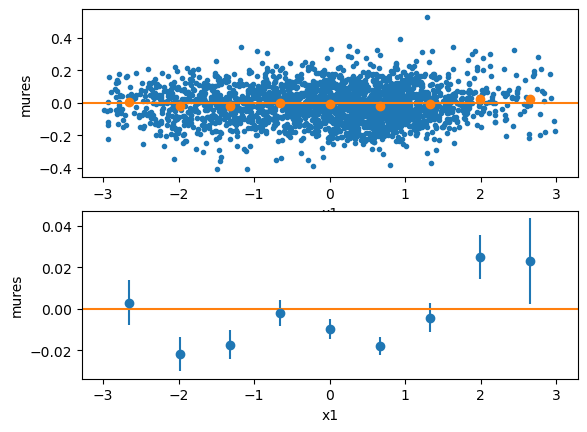

In [49]:
x1_plot = np.array(x1)[saltpar_cuts]

ax1 = plt.subplot(2,1,1)

ax1.plot(x1_plot,mures,'.')

bins= np.linspace(x1_plot.min(),x1_plot.max(),10)
x1_mean, bin_edges, _ = stats.binned_statistic(
    x1_plot, mures, statistic='mean', bins= bins
)

x1_std, bin_edges, _ = stats.binned_statistic(
    x1_plot, mures, statistic='std', bins= bins
)

x1_count, bin_edges, _ = stats.binned_statistic(
    x1_plot, mures, statistic='count', bins= bins
) 

x1_err = x1_std / np.sqrt(x1_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
plt.errorbar(bin_mean, x1_mean, yerr =x1_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('x1')
plt.ylabel('mures')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.errorbar(bin_mean, x1_mean, yerr =x1_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('x1')
plt.ylabel('mures')

Text(0, 0.5, 'mures')

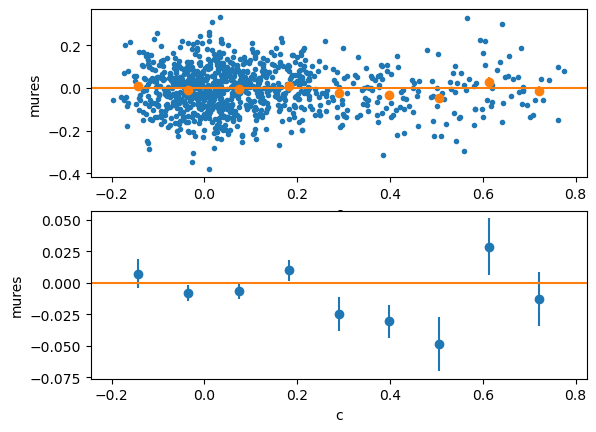

In [50]:
zcut = saltpars["z"]<0.06

c_plot = np.array(c)[saltpar_cuts & zcut]

ax1 = plt.subplot(2,1,1)

ax1.plot(c_plot,mures[zcut],'.')

bins= np.linspace(c_plot.min(),c_plot.max(),10)
c_mean, bin_edges, _ = stats.binned_statistic(
    c_plot, mures[zcut], statistic='mean', bins= bins
)

c_std, bin_edges, _ = stats.binned_statistic(
    c_plot, mures[zcut], statistic='std', bins= bins
)

c_count, bin_edges, _ = stats.binned_statistic(
    c_plot, mures[zcut], statistic='count', bins= bins
) 

c_err = c_std / np.sqrt(c_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
plt.errorbar(bin_mean, c_mean, yerr =c_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('c')
plt.ylabel('mures')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.errorbar(bin_mean, c_mean, yerr =c_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('c')
plt.ylabel('mures')

Text(0, 0.5, 'mures')

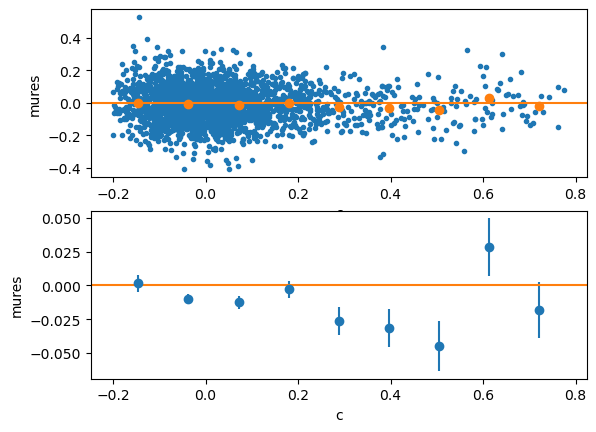

In [51]:
c_plot = np.array(c)[saltpar_cuts]

ax1 = plt.subplot(2,1,1)

ax1.plot(c_plot,mures,'.')

bins= np.linspace(c_plot.min(),c_plot.max(),10)
c_mean, bin_edges, _ = stats.binned_statistic(
    c_plot, mures, statistic='mean', bins= bins
)

c_std, bin_edges, _ = stats.binned_statistic(
    c_plot, mures, statistic='std', bins= bins
)

c_count, bin_edges, _ = stats.binned_statistic(
    c_plot, mures, statistic='count', bins= bins
) 

c_err = c_std / np.sqrt(c_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
plt.errorbar(bin_mean, c_mean, yerr =c_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('c')
plt.ylabel('mures')

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.errorbar(bin_mean, c_mean, yerr =c_err,fmt='o')

plt.axhline(y=0,color=colors[1])

plt.xlabel('c')
plt.ylabel('mures')

Effects maybe simulated

ZTF Photometry "pocket effect" (Fig 2 of ZTF DR2 Overview paper https://arxiv.org/pdf/2409.04346)
<img src="figs/pocket_effect.png" width="400" height="300">
